# Bike Store Data Analysis

## Context

This notebook presents an end-to-end customer analytics pipeline for a bike company,
using transactional data from 2020 to 2022. The analysis is structured in two main modules:

**1. Product Anomaly Detection (Isolation Forest)**  
Unsupervised detection of products with anomalous behavior in terms of total units sold,
total units returned, and return rate. Products that deviate significantly from the overall
distribution are in for further investigation. This is particularly relevant in a bike store
context where accessories, components, and bikes have very different sales volumes and
return patterns.

**2. Customer Segmentation (RFM + Machine Learning)**  
Customers are segmented using the RFM method (Recency, Frequency, Monetary), then
demographic features are incorporated to train Random Forest models that explain and predict
each segment. K-Means clustering is also explored as an alternative approach.

## Data Sources

| Table | Description | Rows |
|---|---|---|
| Sales (2020–2022) | Transactional order data | 56,046 |
| Customers | Demographics and profile | 18,154 |
| Products | Bike and accessories catalog with pricing | 293 |
| Returns | Return records by product and territory | 1,809 |
| Product Categories / Subcategories | Product hierarchy | 4 / 37 |
| Territories | Sales regions | 10 |

## 1. Environment Setup

### 1.1 Libraries

In [188]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1.2 Data Loading

The CSV files for products, sales, returns, and customers are loaded below.
Sales tables from the three available years are consolidated into a single DataFrame.

In [189]:
products = pd.read_csv("data/product_data/products.csv")
product_cat = pd.read_csv("data/product_data/product_categories.csv")
product_subcat = pd.read_csv("data/product_data/product_subcategories.csv")
sales = pd.concat([
    pd.read_csv("data/sales_data/sales_data_2020.csv"),
    pd.read_csv("data/sales_data/sales_data_2021.csv"),
    pd.read_csv("data/sales_data/sales_data_2022.csv")
], ignore_index=True)
returns = pd.read_csv("data/sales_data/returns_data.csv")
customers = pd.read_csv("data/customers.csv", encoding='cp1252')

In [190]:
for name, df in {
    "Products": products,
    "Product Categories": product_cat,
    "Product Subcategories": product_subcat,
    "Sales": sales,
    "Returns": returns,
    "Customers": customers,
}.items():
    print(f"{'─'*40}")
    print(f"  {name}")
    print(df.info())
    print()

────────────────────────────────────────
  Products
<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProductKey             293 non-null    int64  
 1   ProductSubcategoryKey  293 non-null    int64  
 2   ProductSKU             293 non-null    str    
 3   ProductName            293 non-null    str    
 4   ModelName              293 non-null    str    
 5   ProductDescription     293 non-null    str    
 6   ProductColor           243 non-null    str    
 7   ProductSize            293 non-null    str    
 8   ProductStyle           293 non-null    str    
 9   ProductCost            293 non-null    float64
 10  ProductPrice           293 non-null    float64
dtypes: float64(2), int64(2), str(7)
memory usage: 25.3 KB
None

────────────────────────────────────────
  Product Categories
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0

## 2. Product Anomaly Detection

### 2.1 Feature Engineering

For each product, three metrics are computed from the sales and returns data:
- **total_sold**: total units sold across the period
- **total_returned**: total units returned
- **return_rate**: proportion of sold units that were returned

In [191]:
total_sold = sales.groupby('ProductKey')['OrderQuantity'].sum()
total_returned = returns.groupby('ProductKey')['ReturnQuantity'].sum()

In [192]:
sales_returns = pd.DataFrame({
    'total_sold': total_sold,
    'total_returned': total_returned
}).fillna(0)

sales_returns['return_rate'] = sales_returns['total_returned'] / sales_returns['total_sold']

In [193]:
sales_returns = sales_returns.reset_index().merge(
    products[['ProductKey', 'ProductName', 'ProductSubcategoryKey']],
    on='ProductKey',
    how='left'
)

In [194]:
sales_returns.head()

,ProductKey,total_sold,total_returned,return_rate,ProductName,ProductSubcategoryKey
0,214,2099,70.0,0.033349,"Sport-100 Helmet, Red",31
1,215,1940,52.0,0.026804,"Sport-100 Helmet, Black",31
2,220,1995,66.0,0.033083,"Sport-100 Helmet, Blue",31
3,223,4151,46.0,0.011082,AWC Logo Cap,19
4,226,392,12.0,0.030612,"Long-Sleeve Logo Jersey, S",21


### 2.2 Isolation Forest Model

Isolation Forest is an unsupervised anomaly detection algorithm that isolates observations
by randomly partitioning the feature space. Points that require fewer splits to be isolated
are considered anomalies — they are rare and far from the bulk of the distribution.

The model is trained on the three product-level features, with `contamination=0.05`,
meaning roughly 5% of products are expected to be flagged as anomalous.

In [195]:
from sklearn.ensemble import IsolationForest

features = ['total_sold', 'total_returned', 'return_rate']
X = sales_returns[features]

model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [196]:
sales_returns['anomaly'] = model.predict(X)
sales_returns['anomaly_score'] = model.decision_function(X)
sales_returns['is_anomaly'] = sales_returns['anomaly'] == -1

### 2.3 Anomalous Products

Products flagged by the model (`is_anomaly = True`). These stand out due to unusually
high sales volume, high return counts, or an abnormal return rate relative to the rest
of the catalog.

In [197]:
display(
    sales_returns[sales_returns['is_anomaly']]
    [['ProductName', 'total_sold', 'total_returned', 'return_rate', 'anomaly_score']]
    .sort_values('anomaly_score')
    .reset_index(drop=True)
)

,ProductName,total_sold,total_returned,return_rate,anomaly_score
0,Water Bottle - 30 oz.,7967,155.0,0.019455,-0.208772
1,Patch Kit/8 Patches,5898,95.0,0.016107,-0.068407
2,Mountain Tire Tube,5678,93.0,0.016379,-0.061561
3,"Road-650 Red, 52",51,6.0,0.117647,-0.059573
4,Mountain Bottle Cage,3810,77.0,0.020210,-0.029757
5,AWC Logo Cap,4151,46.0,0.011082,-0.018840
6,Road Tire Tube,4327,67.0,0.015484,-0.003632


### 2.4 Descriptive Statistics

In [198]:
display(
    sales_returns[['total_sold', 'total_returned', 'return_rate']]
    .describe()
    .T
    .round(3)
)

,count,mean,std,min,25%,50%,75%,max
total_sold,130.0,647.492,1257.134,22.0,63.00,180.500,420.000,7967.000
total_returned,130.0,14.062,22.470,0.0,2.25,6.500,15.000,155.000
return_rate,130.0,0.031,0.017,0.0,0.02,0.029,0.038,0.118


### 2.5 Visualization

Each point represents a product. Anomalies are highlighted in red. Products with a
return rate above 6% are labeled — these are candidates for quality or logistics review.

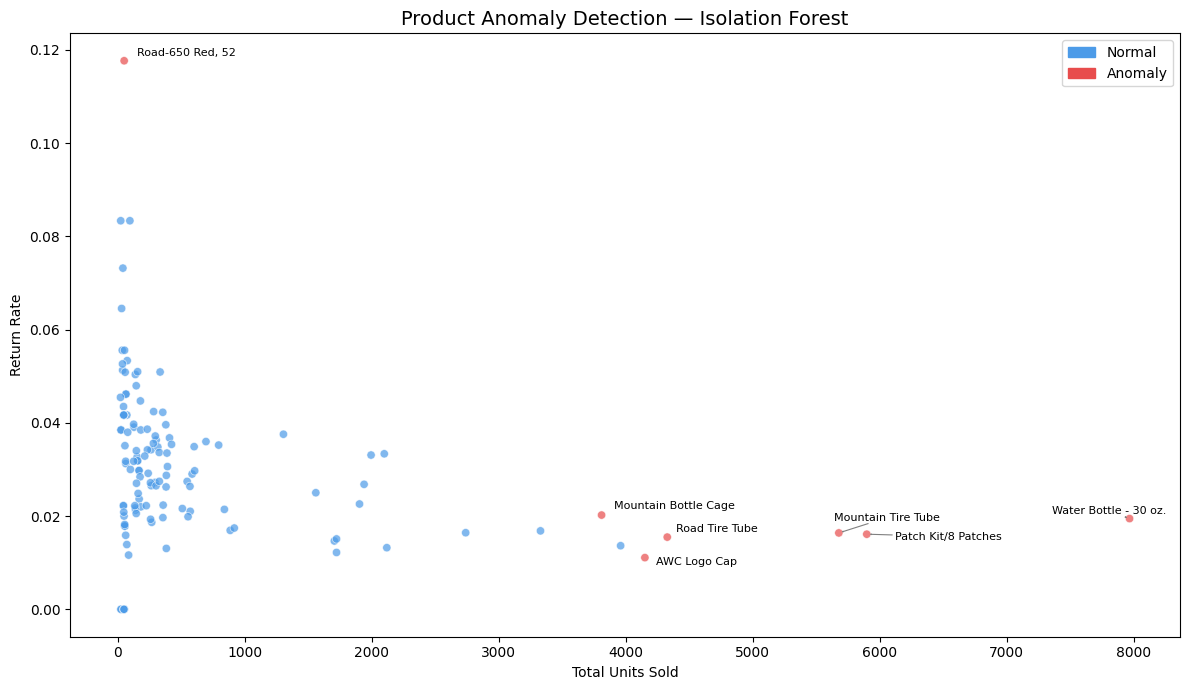

In [199]:
import matplotlib.patches as mpatches
from adjustText import adjust_text

colors = sales_returns['is_anomaly'].map({False: '#4C9BE8', True: '#E84C4C'})

plt.figure(figsize=(12, 7))
plt.scatter(
    sales_returns['total_sold'],
    sales_returns['return_rate'],
    c=colors, alpha=0.7, edgecolors='white', linewidths=0.5
)

anomalies = sales_returns[sales_returns['is_anomaly']]
texts = []
for _, row in anomalies.iterrows():
    texts.append(plt.text(
        row['total_sold'], row['return_rate'],
        row['ProductName'], fontsize=8
    ))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.xlabel('Total Units Sold')
plt.ylabel('Return Rate')
plt.title('Product Anomaly Detection — Isolation Forest', fontsize=14)
plt.legend(handles=[
    mpatches.Patch(color='#4C9BE8', label='Normal'),
    mpatches.Patch(color='#E84C4C', label='Anomaly'),
])
plt.tight_layout()
plt.show()

### 2.6 High Return Rate Products

Products with a return rate above 6%, sorted descending. These fall outside the typical
range and may warrant a quality or customer experience review.

In [200]:
display(sales_returns[sales_returns['return_rate'] > 0.06]
        [['ProductName', 'total_sold', 'total_returned', 'return_rate']]
        .sort_values('return_rate', ascending=False))

,ProductName,total_sold,total_returned,return_rate
18,"Road-650 Red, 52",51,6.0,0.117647
27,"Mountain-100 Silver, 44",24,2.0,0.083333
103,"Touring-2000 Blue, 46",96,8.0,0.083333
126,"Mountain-500 Black, 52",41,3.0,0.073171
31,"Mountain-100 Black, 44",31,2.0,0.064516


## 3. Customer Segmentation

### 3.1 RFM Analysis

RFM is a behavior-based segmentation framework that scores customers across three dimensions:

- **Recency**: how recently a customer made a purchase (lower = better)
- **Frequency**: how many distinct orders a customer placed
- **Monetary**: total revenue generated by the customer

Each metric is scored from 1 to 5 using quintiles, and the combination of scores
determines the customer's segment.

In [201]:
mask = pd.to_numeric(customers['CustomerKey'], errors='coerce').isna()
print(f"Empty values: {mask.sum()}")
print(customers[mask]['CustomerKey'].unique())

Empty values: 6
<StringArray>
['30---', nan, 'Export date 20230101 14:59:17', 'Source AW_Cust_Master']
Length: 4, dtype: str


#### Data Preparation

Before computing RFM, the sales table is enriched with product pricing data to calculate
revenue per order line. A reference date is set to the day after the last recorded order.

In [202]:
customers = customers[pd.to_numeric(customers['CustomerKey'], errors='coerce').notna()]

customers['CustomerKey'] = customers['CustomerKey'].astype(int)

print(customers['CustomerKey'].dtype)
print(customers.shape)

int64
(18148, 13)


In [203]:
sales_full = (
    sales
    .merge(products[['ProductKey', 'ProductPrice', 'ProductSubcategoryKey']], 
           on='ProductKey', how='left')
    .merge(product_subcat[['ProductSubcategoryKey', 'ProductCategoryKey']], 
           on='ProductSubcategoryKey', how='left')
    .merge(product_cat[['ProductCategoryKey', 'CategoryName']], 
           on='ProductCategoryKey', how='left')
)

sales_full['Revenue'] = sales_full['OrderQuantity'] * sales_full['ProductPrice']

print(sales_full.shape)
sales_full.head()

(56046, 13)


,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductPrice,ProductSubcategoryKey,ProductCategoryKey,CategoryName,Revenue
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,699.0982,2,1,Bikes,699.0982
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,3578.2700,2,1,Bikes,3578.2700
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,3374.9900,1,1,Bikes,3374.9900
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,699.0982,2,1,Bikes,699.0982
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,3578.2700,2,1,Bikes,3578.2700


In [204]:
sales_full['OrderDate'] = pd.to_datetime(sales_full['OrderDate'])

reference_date = sales_full['OrderDate'].max() + pd.Timedelta(days=1)
print(reference_date)

2022-07-01 00:00:00


#### RFM Computation

In [205]:
rfm = sales_full.groupby('CustomerKey').agg(
    Recency = ('OrderDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('OrderNumber', 'nunique'),
    Monetary = ('Revenue', 'sum')
).reset_index()

print(rfm.shape)
rfm.describe()

(17416, 4)


,CustomerKey,Recency,Frequency,Monetary
count,17416.000000,17416.000000,17416.000000,17416.000000
mean,20132.981339,159.128445,1.444878,1430.557351
std,5309.024004,118.232324,1.032270,1886.765516
min,11000.000000,1.000000,1.000000,2.290000
25%,15540.750000,65.000000,1.000000,69.990000
50%,20097.500000,144.000000,1.000000,539.990000
75%,24708.250000,234.000000,2.000000,2256.650400
max,29483.000000,912.000000,26.000000,12407.954500


#### Distribution of RFM Metrics

Boxplots with the 25th and 75th percentile reference lines for each metric.

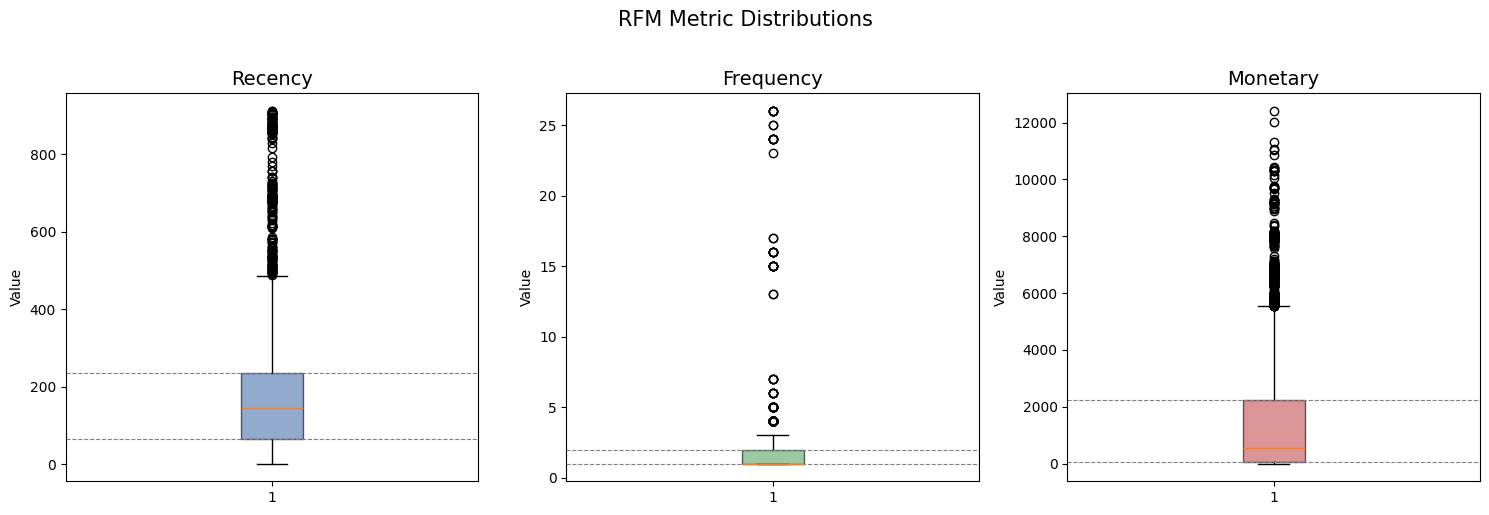

In [206]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Recency', 'Frequency', 'Monetary']
colors  = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric, color in zip(axes, metrics, colors):
    ax.boxplot(rfm[metric], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(metric, fontsize=14)
    ax.set_ylabel('Value')
    ax.axhline(rfm[metric].quantile(0.25), color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(rfm[metric].quantile(0.75), color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('RFM Metric Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### Monetary — Log Transformation

The Monetary distribution is right-skewed. A log transformation reveals a bimodal
structure, suggesting two distinct customer spending profiles within the base.

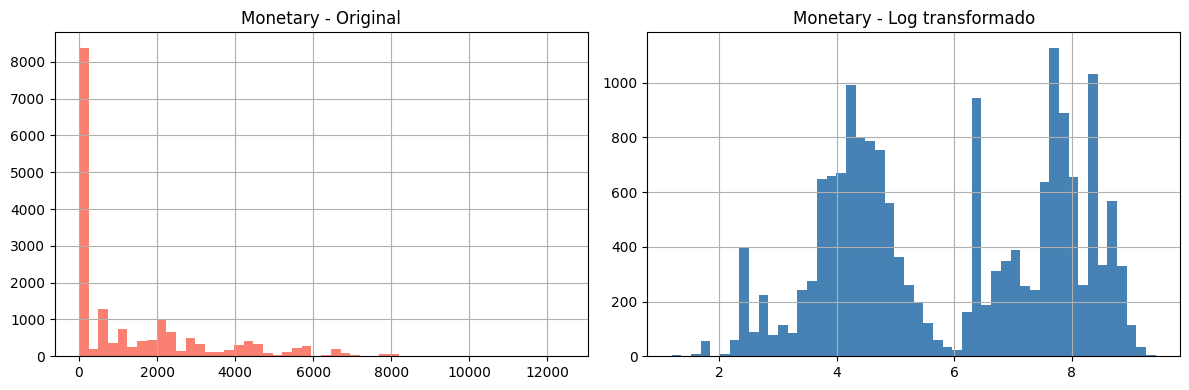

In [207]:
import numpy as np
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rfm['Monetary'].hist(ax=axes[0], bins=50, color='salmon')
axes[0].set_title('Monetary - Original')
rfm['Monetary_log'].hist(ax=axes[1], bins=50, color='steelblue')
axes[1].set_title('Monetary - Log transformado')
plt.tight_layout()
plt.show()

### 3.2 RFM Scoring & Segmentation

Each metric is divided into 5 quintiles. Recency is scored inversely (lower recency = higher score).
The three scores are combined into a composite `RFM_Score`, which is then mapped
to a business segment using a rule-based classification.

In [208]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.head(10)

,CustomerKey,Recency,Frequency,Monetary,Monetary_log,R_Score,F_Score,M_Score,RFM_Score
0,11000,239,2,4656.3896,8.446210,2,4,5,245
1,11001,19,2,2821.2122,7.945276,5,4,5,545
2,11002,308,2,4466.8124,8.404654,1,4,5,145
3,11003,232,2,4532.9866,8.419357,2,4,5,245
4,11004,241,2,4568.0838,8.427068,2,4,5,245
5,11005,240,2,4502.7596,8.412668,2,4,5,245
6,11007,284,2,4590.7424,8.432015,1,4,5,145
7,11008,301,2,4502.6982,8.412654,1,4,5,145
8,11009,233,2,4471.3924,8.405679,2,4,5,245
9,11010,219,2,4459.1008,8.402927,2,4,5,245


In [209]:
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4 and m >= 4:       # ← nuevo
        return "Can't Lose Them"
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
Loyal Customers        4537
Potential Loyalists    2605
New Customers          2574
At Risk                2261
Champions              1968
Lost                   1788
Can't Lose Them        1683
Name: count, dtype: int64

### 3.3 Segment Distribution

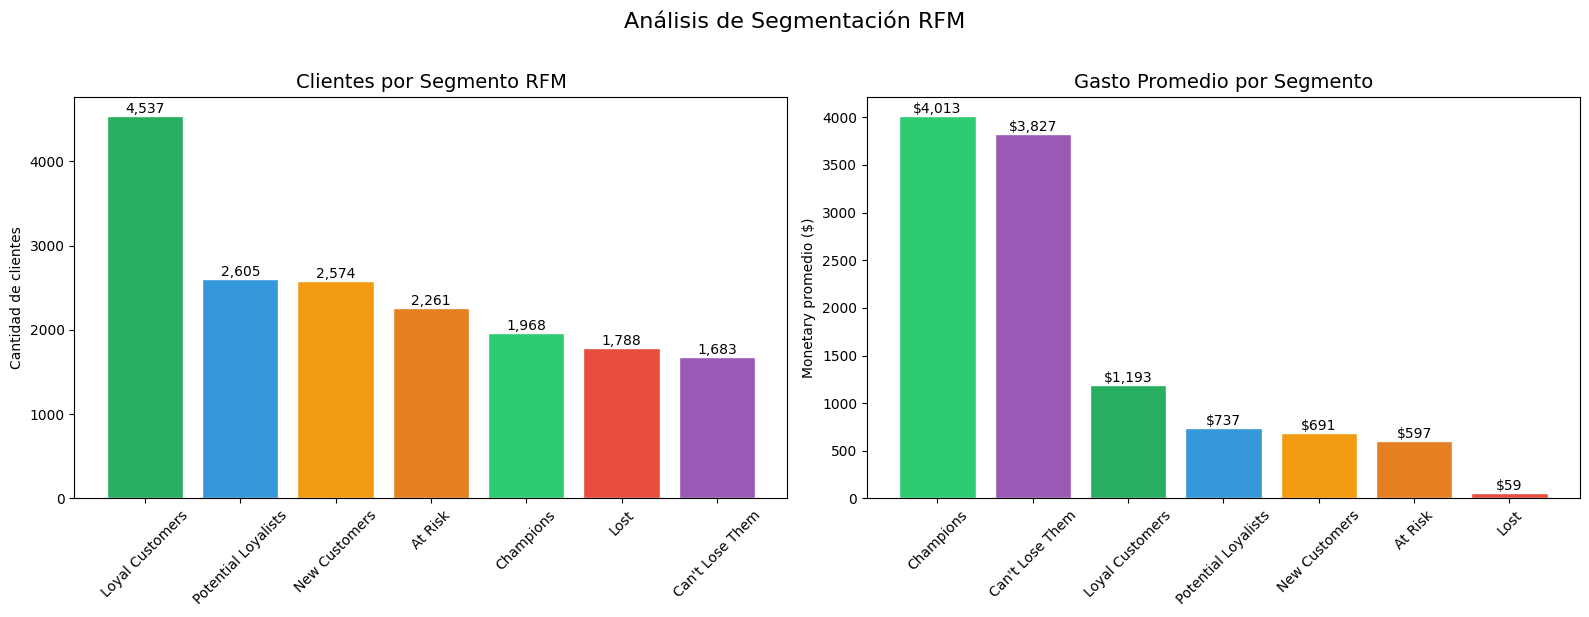

In [210]:
color_map = {
    'Champions':          '#2ecc71',
    'Loyal Customers':    '#27ae60',
    'Potential Loyalists':'#3498db',
    'New Customers':      '#f39c12',
    'At Risk':            '#e67e22',
    "Can't Lose Them":    '#9b59b6',
    'Lost':               '#e74c3c',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

conteo = rfm['Segment'].value_counts()
axes[0].bar(conteo.index, conteo.values, 
            color=[color_map[s] for s in conteo.index], edgecolor='white')
axes[0].set_title('Clientes por Segmento RFM', fontsize=14)
axes[0].set_ylabel('Cantidad de clientes')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)


gasto = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1].bar(gasto.index, gasto.values,
            color=[color_map[s] for s in gasto.index], edgecolor='white')
axes[1].set_title('Gasto Promedio por Segmento', fontsize=14)
axes[1].set_ylabel('Monetary promedio ($)')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'${int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.suptitle('Análisis de Segmentación RFM', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. Predictive Modeling

The goal of this section is to understand how well demographic features explain
RFM-based segments. Two approaches are used:

- **Random Forest Classifier**: predicts the RFM segment from demographic data
- **Random Forest Regressor**: predicts each RFM metric individually

This helps assess whether customer demographics are meaningful drivers of purchasing
behavior, or whether the segments are largely independent of who the customer is.

### 4.1 Feature Engineering — Demographics

Customer age is derived from birth date. Education level is ordinally encoded,
and categorical variables are one-hot encoded.

In [211]:
customers['BirthDate'] = pd.to_datetime(customers['BirthDate'])
customers['Age'] = (reference_date - customers['BirthDate']).dt.days // 365

In [212]:
education_order = {
    'Partial High School': 1,
    'High School':         2,
    'Partial College':     3,
    'Bachelors':           4,
    'Graduate Degree':     5
}

customers['EducationLevel'] = customers['EducationLevel'].map(education_order)

In [213]:
customers_encoded = pd.get_dummies(customers[['CustomerKey', 'Age', 'AnnualIncome', 
                                               'TotalChildren', 'EducationLevel',
                                               'Occupation', 'Gender', 
                                               'MaritalStatus', 'HomeOwner']],
                                    columns=['Occupation', 'Gender', 
                                             'MaritalStatus', 'HomeOwner'],
                                    drop_first=True,
                                    dtype=int)

customers_encoded

,CustomerKey,Age,AnnualIncome,TotalChildren,EducationLevel,Occupation_Management,Occupation_Manual,Occupation_Professional,Occupation_Skilled Manual,Gender_M,MaritalStatus_S,HomeOwner_Y
0,11000,56,90000.0,2.0,4,0,0,1,0,1,0,1
1,11001,57,60000.0,3.0,4,0,0,1,0,1,1,0
2,11002,56,60000.0,3.0,4,0,0,1,0,1,0,1
3,11003,54,70000.0,0.0,4,0,0,1,0,0,1,0
4,11004,53,80000.0,5.0,4,0,0,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18143,29479,64,30000.0,1.0,5,0,0,0,0,1,0,1
18144,29480,61,30000.0,3.0,5,0,0,0,0,0,1,1
18145,29481,62,30000.0,3.0,5,0,0,0,0,1,1,0
18146,29482,63,30000.0,3.0,4,0,0,0,0,1,0,1


### 4.2 Merging RFM with Demographics

In [214]:
rfm_full = rfm.merge(customers_encoded, on='CustomerKey', how='left')

print(rfm_full.shape)
rfm_full.isnull().sum()

(17416, 21)


CustomerKey                  0
Recency                      0
Frequency                    0
Monetary                     0
Monetary_log                 0
R_Score                      0
F_Score                      0
M_Score                      0
RFM_Score                    0
Segment                      0
Age                          0
AnnualIncome                 0
TotalChildren                0
EducationLevel               0
Occupation_Management        0
Occupation_Manual            0
Occupation_Professional      0
Occupation_Skilled Manual    0
Gender_M                     0
MaritalStatus_S              0
HomeOwner_Y                  0
dtype: int64

### 4.3 Random Forest Classifier — Segment Prediction

A Random Forest Classifier is trained to predict the RFM segment from demographic
features alone. This tests whether demographics are predictive of segment membership.

In [215]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Y = segmentos RFM
le = LabelEncoder()
y = le.fit_transform(rfm_full['Segment'])

# X = solo features demográficas
demo_features = ['Age', 'AnnualIncome', 'TotalChildren', 'EducationLevel',
                 'Occupation_Management', 'Occupation_Manual', 
                 'Occupation_Professional', 'Occupation_Skilled Manual',
                 'Gender_M', 'MaritalStatus_S', 'HomeOwner_Y']

X = rfm_full[demo_features]

print("Clases:", le.classes_)
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Clases: ['At Risk' "Can't Lose Them" 'Champions' 'Lost' 'Loyal Customers'
 'New Customers' 'Potential Loyalists']
Shape X: (17416, 11)
Shape y: (17416,)


In [216]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Accuracy:", round(rf.score(X_test, y_test), 3))

Accuracy: 0.243


#### Feature Importance

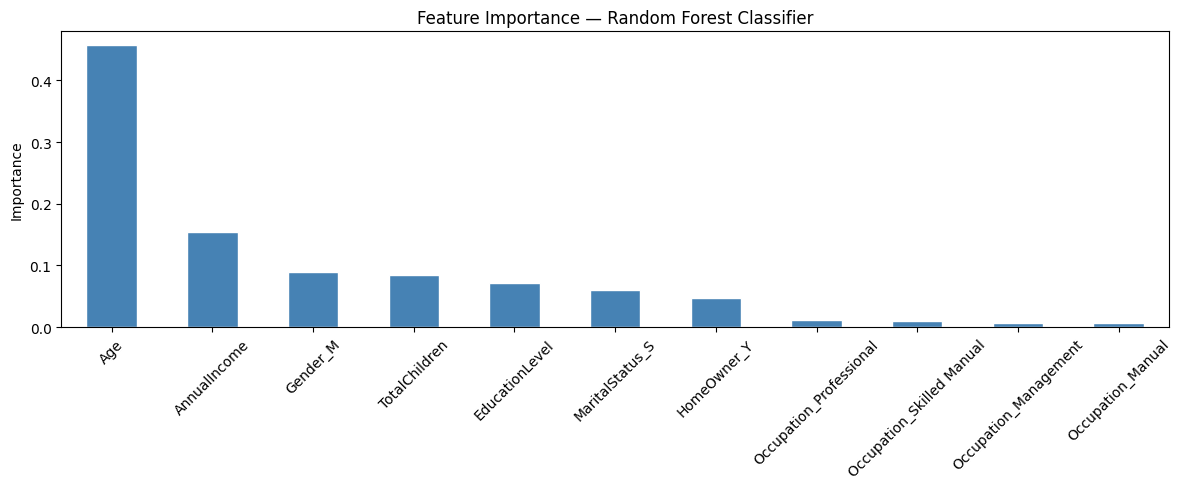

In [217]:
importances = pd.Series(rf.feature_importances_, index=demo_features)
importances.sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 5), color='steelblue', edgecolor='white'
)
plt.title('Feature Importance — Random Forest Classifier')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Random Forest Regressor — RFM Metric Prediction

Three separate regressors are trained, one per RFM metric. Monetary is modeled
in log scale to reduce the effect of skewness. R² scores indicate how much variance
in each metric is explained by demographics alone.

In [218]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

targets = {
    'Recency': rfm_full['Recency'],
    'Frequency': rfm_full['Frequency'],
    'Monetary': rfm_full['Monetary_log']  # usamos log
}

results = {}

for target_name, y_target in targets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_target, test_size=0.2, random_state=42
    )
    
    rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf_reg.fit(X_train, y_train)
    
    r2 = r2_score(y_test, rf_reg.predict(X_test))
    results[target_name] = {
        'r2': round(r2, 3),
        'importances': pd.Series(rf_reg.feature_importances_, index=demo_features)
    }
    print(f"{target_name} → R²: {round(r2, 3)}")

Recency → R²: -0.204
Frequency → R²: -0.339
Monetary → R²: 0.185


#### Feature Importance — Monetary Regressor

Monetary shows the highest (though still moderate) R², making it the most tractable
target for demographic prediction. Income and age are the dominant drivers.

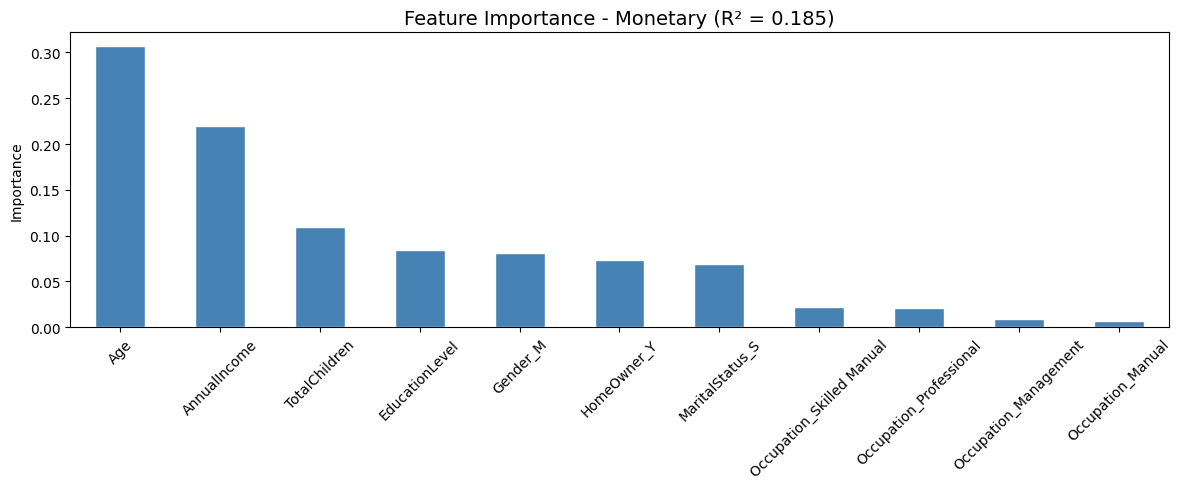

In [219]:
importances_monetary = results['Monetary']['importances'].sort_values(ascending=False)

importances_monetary.plot(
    kind='bar', figsize=(12, 5), color='steelblue', edgecolor='white'
)
plt.title('Feature Importance - Monetary (R² = 0.185)', fontsize=14)
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Clustering Exploration — K-Means

As a complementary approach, K-Means clustering is applied to the RFM metrics combined
with demographic features. The goal is to assess whether a purely data-driven grouping
produces more natural segments than the rule-based RFM approach.

### 5.1 Feature Scaling

RFM and demographic features are standardized before clustering. Variables with
negligible importance in both the classifier and the regressors are excluded —
retaining only the features that showed meaningful predictive signal reduces noise
and avoids artificially inflating the feature space.

Features are then standardized using `StandardScaler`, as K-Means is sensitive
to differences in scale across variables.

In [220]:
from sklearn.preprocessing import StandardScaler

clustering_features = ['Recency', 'Frequency', 'Monetary_log',
                        'Age', 'AnnualIncome', 'TotalChildren',
                        'EducationLevel', 'Gender_M', 
                        'HomeOwner_Y', 'MaritalStatus_S']

X_cluster = rfm_full[clustering_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(X_scaled.shape)

(17416, 10)


### 5.2 Optimal K — Elbow Method & Silhouette Score

Two complementary metrics are used to evaluate cluster quality across a range of K values:
- **Inertia (Elbow Method)**: measures within-cluster sum of squared distances
- **Silhouette Score**: measures how well-separated clusters are (higher = better, max = 1)

In [221]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k}  →  Inertia: {kmeans.inertia_:,.0f}  |  Silhouette: {silhouette_score(X_scaled, kmeans.labels_):.3f}")

K=2  →  Inertia: 151,774  |  Silhouette: 0.135
K=3  →  Inertia: 138,803  |  Silhouette: 0.122
K=4  →  Inertia: 129,317  |  Silhouette: 0.120
K=5  →  Inertia: 121,014  |  Silhouette: 0.123
K=6  →  Inertia: 114,588  |  Silhouette: 0.121
K=7  →  Inertia: 109,200  |  Silhouette: 0.123
K=8  →  Inertia: 105,327  |  Silhouette: 0.118
K=9  →  Inertia: 100,681  |  Silhouette: 0.123
K=10  →  Inertia: 97,294  |  Silhouette: 0.126


### 5.3 Results

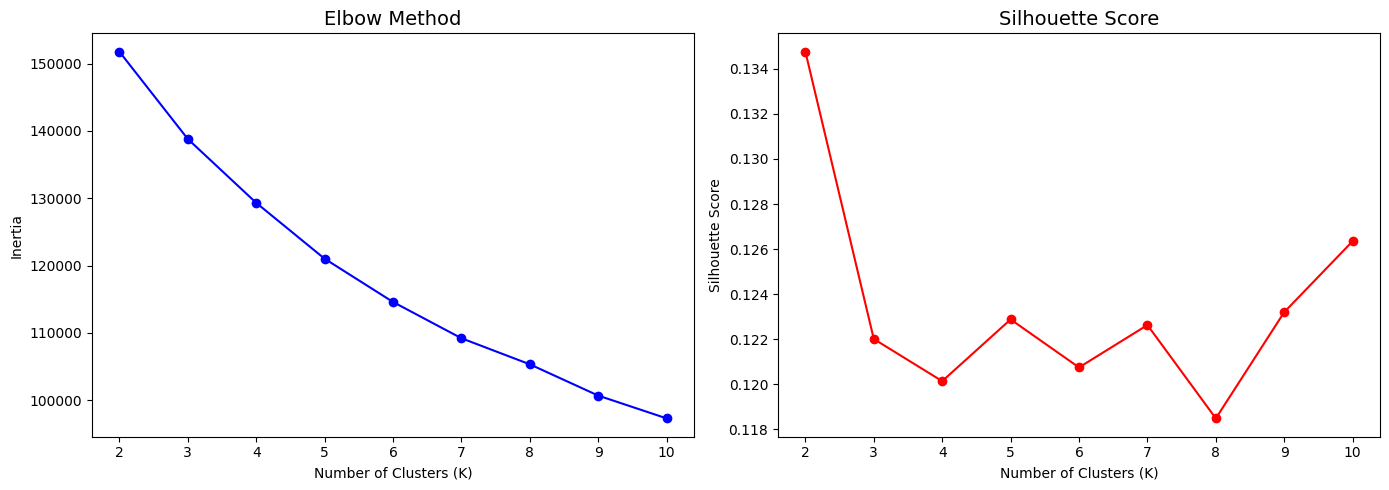

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method', fontsize=14)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_title('Silhouette Score', fontsize=14)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

### 5.4 Interpretation

Silhouette scores across all tested K values remain low (0.12–0.13), indicating that
the data does not have a strong natural cluster structure. Forcing K-Means under these
conditions produces groupings that are more a mathematical artifact than meaningful
customer groups.

This result supports the decision to rely on the **rule-based RFM segmentation**,
which produces interpretable and actionable segments grounded in business logic
rather than geometric proximity in feature space.

## 6. Conclusions

### 6.1 Segment Summary

In [223]:
summary = rfm_full.groupby('Segment').agg(
    Clients = ('CustomerKey', 'count'),
    Recency_avg = ('Recency', 'mean'),
    Frequency_avg = ('Frequency', 'mean'),
    Monetary_avg = ('Monetary', 'mean'),
    Age_avg = ('Age', 'mean'),
    Income_avg = ('AnnualIncome', 'mean')
).round(1)

# Ordenar por Monetary promedio descendente
summary = summary.sort_values('Monetary_avg', ascending=False)

# Formatear para mejor lectura
summary['Monetary_avg'] = summary['Monetary_avg'].apply(lambda x: f'${x:,.0f}')
summary['Income_avg'] = summary['Income_avg'].apply(lambda x: f'${x:,.0f}')

summary

,Clients,Recency_avg,Frequency_avg,Monetary_avg,Age_avg,Income_avg
Segment,,,,,,
Champions,1968,53.4,2.4,"$4,013",59.2,"$61,367"
Can't Lose Them,1683,289.1,1.9,"$3,828",58.1,"$59,346"
Loyal Customers,4537,94.7,1.7,"$1,193",59.9,"$57,679"
Potential Loyalists,2605,201.1,1.0,$737,60.0,"$56,534"
New Customers,2574,53.7,1.0,$692,60.9,"$58,726"
At Risk,2261,276.8,1.1,$598,59.9,"$53,689"
Lost,1788,258.4,1.0,$60,61.1,"$54,284"


### 6.2 Key Findings

**Product Anomaly Detection**
- The Isolation Forest flagged 7 products (~5% of the catalog) as anomalous.
- Two distinct anomaly types were identified: products with exceptionally high sales
  volume (e.g. Water Bottle, Patch Kit) and products with an unusually high return
  rate (e.g. Road-650 Red, 52).
- High-volume anomalies are likely supply chain or demand outliers; high return-rate
  products may indicate quality or sizing issues worth investigating.

**Customer Segmentation**
- The RFM model identified 7 actionable segments across 17,416 customers.
- **Champions** and **Can't Lose Them** together account for the highest average
  spend ($4,013 and $3,828 respectively) and should be prioritized for retention.
- **Loyal Customers** represent the largest segment (4,537 customers) with consistent
  mid-range spending — a strong base for upsell campaigns.
- **Lost** and **At Risk** customers show low recency and monetary value,
  signaling the need for targeted reactivation strategies.

**Predictive Modeling**
- Demographic features show limited predictive power over RFM metrics,
  with R² values below 0.20 across all three regressors.
- This suggests that purchasing behavior in this customer base is driven more
  by individual preferences and timing than by demographic profile alone.
- K-Means clustering confirmed this finding — no strong natural groupings
  emerged from the data, reinforcing the value of the rule-based RFM approach